# Mesh Tutorial 7: Simulation Domains with DomainMesh

Boundary conditions determine the physics. Without them, a PDE isn't well-posed -
"solve Navier-Stokes on this mesh" is meaningless until you specify which walls are
no-slip, where the inflow is, and what the freestream velocity is.

The challenge is that interior and boundary data are **heterogeneous**:

- The **interior** is a triangulated volume or surface (`Mesh[2, 2]` or `Mesh[2, 3]`)
  carrying fields like pressure and velocity.
- Each **boundary** may be a different manifold dimension (`Mesh[1, 2]` curves,
  `Mesh[2, 3]` surfaces) with its own fields (wall shear, prescribed velocity).
- **Domain-level metadata** (Reynolds number, Mach number) applies globally.

`DomainMesh` groups these into a single tensorclass:

| Field | Type | Purpose |
|-------|------|----------|
| `interior` | `Mesh` | Volume mesh, point cloud, or prediction surface |
| `boundaries` | `dict[str, Mesh]` | Named boundary patches keyed by BC type |
| `global_data` | `dict[str, Tensor]` | Domain-level quantities (Re, Mach, etc.) |

Operations like rotation, scaling, and validation propagate automatically -
the interior, all boundaries, and their attached data move together.

---

## Why DomainMesh?

Production pipelines like GLOBE already need this pattern. DrivAerML manually
assembles a `prediction_mesh`, a `boundary_meshes: TensorDict[str, Mesh]` dict,
and separate `global_data` - then passes them around as loose fields. Every new
model reimplements this bundling.

`DomainMesh` standardizes it at a **model-agnostic** level: not prescriptive in
how you use boundary info in your model, only in how you represent it. Key features:

- **`apply(fn)`**: Apply any `Mesh -> Mesh` function to all meshes at once
- **Geometric transforms**: `translate`, `rotate`, `scale` with optional vector-field
  co-rotation - enabling on-the-fly data augmentation for quasi-equivariance
- **Serialization**: Saves/loads like a `Mesh`, with a directory structure that
  allows on-disk surgery on individual components
- **Validation**: Aggregate quality checks across the entire domain

In this tutorial we'll build a `DomainMesh` from a real AirFRANS CFD sample -
a 2D RANS simulation of flow around an airfoil.

## What You'll Learn

1. Load a real CFD domain from VTK files (interior + boundary meshes)
2. Project 3D simulation data to 2D and assemble into a `DomainMesh`
3. Inspect domain properties and iterate over meshes
4. Use geometric transforms for data augmentation (quasi-equivariance)
5. Validate mesh quality across the domain
6. Visualize the pressure field around the airfoil

In [15]:
from pathlib import Path

import pyvista as pv
import torch

from physicsnemo.mesh import DomainMesh, Mesh
from physicsnemo.mesh.io import from_pyvista
from physicsnemo.mesh.projections import project

## Section 1: Loading a Real CFD Domain

Each AirFRANS sample directory contains three VTK files from a 2D RANS simulation:

| File | Contents | Target type |
|------|----------|-------------|
| `*_internal.vtu` | Triangulated flow field with pressure, velocity, etc. | `Mesh[2, 2]` |
| `*_aerofoil.vtp` | Airfoil surface polyline (no-slip wall) | `Mesh[1, 2]` |
| `*_freestream.vtp` | Outer domain boundary polyline (far-field) | `Mesh[1, 2]` |

The VTK files are 3D (with a constant z-coordinate from the extrusion), so we
use `project(keep_dims=[0, 1])` to drop the z-axis and get proper 2D meshes.
This is the same loading pattern used by the GLOBE AirFRANS pipeline.

In [16]:
# Point this to any AirFRANS sample directory
SAMPLE_DIR = (
    Path.home()
    / "gh/aerodynamics_datasets/airfrans/Dataset"
    / "airFoil2D_SST_31.382_3.588_1.994_6.206_0.0_13.271"
)
base = SAMPLE_DIR.name

# Interior: triangulated flow field -> Mesh[2, 2]
# transform_point_data=True projects vector fields (e.g. velocity) alongside coordinates
raw_interior = project(
    from_pyvista(pv.read(str(SAMPLE_DIR / f"{base}_internal.vtu"))),
    keep_dims=[0, 1],
    transform_point_data=True,
)

# Keep only the physics fields (strip VTK metadata like TimeValue, vtkOriginalPointIds)
interior = Mesh(
    points=raw_interior.points,
    cells=raw_interior.cells,
    point_data=raw_interior.point_data.select("p", "U", "nut"),
)
print(f"Interior: Mesh[{interior.n_manifold_dims}, {interior.n_spatial_dims}]")
print(f"  {interior.n_points} points, {interior.n_cells} cells")
print(f"  point_data: {list(interior.point_data.keys())}")

Interior: Mesh[2, 2]
  180790 points, 359058 cells
  point_data: ['p', 'U', 'nut']


In [17]:
# Airfoil boundary (no-slip wall) -> Mesh[1, 2]
# transform_point_data=True projects vector fields (U, Normals) from 3D to 2D
airfoil = project(
    from_pyvista(pv.read(str(SAMPLE_DIR / f"{base}_aerofoil.vtp")), manifold_dim=1),
    keep_dims=[0, 1],
    transform_point_data=True,
)

# Freestream boundary (far-field) -> Mesh[1, 2]
freestream = project(
    from_pyvista(pv.read(str(SAMPLE_DIR / f"{base}_freestream.vtp")), manifold_dim=1),
    keep_dims=[0, 1],
    transform_point_data=True,
    transform_cell_data=True,
)

print(f"Airfoil:    Mesh[{airfoil.n_manifold_dims}, {airfoil.n_spatial_dims}], "
      f"{airfoil.n_points} points, {airfoil.n_cells} edges")
print(f"Freestream: Mesh[{freestream.n_manifold_dims}, {freestream.n_spatial_dims}], "
      f"{freestream.n_points} points, {freestream.n_cells} edges")

Airfoil:    Mesh[1, 2], 1018 points, 1018 edges
Freestream: Mesh[1, 2], 1728 points, 1728 edges


### Assembling the Domain

The two boundary meshes represent the physical boundary conditions:

- **Airfoil** (no-slip wall): the solid body where velocity is zero
- **Freestream** (far-field): the outer domain boundary at the edge of the computational domain

Each boundary carries its own physics fields (`p`, `U`, `nut`) - this heterogeneity
is the whole point. The interior is a `Mesh[2, 2]` triangulation while the boundaries
are `Mesh[1, 2]` curves, each with data appropriate to its role.

Domain-level quantities like the freestream velocity vector `U_inf` go in `global_data`.

In [18]:
# Compute freestream velocity from the far-field boundary
U_inf = freestream.cell_data["U"].mean(dim=0)
print(f"Freestream velocity: {U_inf}")
print()

# Keep the shared physics fields on each boundary (strip VTK metadata like Normals, Length)
physics_fields = ("p", "U", "nut")

# Assemble the domain
dm = DomainMesh(
    interior=interior,
    boundaries={
        "airfoil": Mesh(
            points=airfoil.points,
            cells=airfoil.cells,
            point_data=airfoil.point_data.select(*physics_fields),
        ),
        "freestream": Mesh(
            points=freestream.points,
            cells=freestream.cells,
            point_data=freestream.point_data.select(*physics_fields),
        ),
    },
    global_data={"U_inf": U_inf},
)

print(dm)

Freestream velocity: tensor([31.3015,  1.9567])

DomainMesh(
    interior: Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=180790, n_cells=359058)
        point_data: {U: (2,), nut: (), p: ()}
    boundaries:
        airfoil   : Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1018, n_cells=1018)
            point_data: {U: (2,), nut: (), p: ()}
        freestream: Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1728, n_cells=1728)
            point_data: {U: (2,), nut: (), p: ()}
    global_data: {U_inf: (2,)}
)


## Section 2: Inspecting the Domain

A `DomainMesh` provides properties and iterators for exploring its contents.

In [19]:
print(f"Boundaries ({len(dm.boundary_names)}): {dm.boundary_names}")
print()

# Access individual boundaries
airfoil_bc = dm.boundaries["airfoil"]
print(f"Airfoil boundary: {airfoil_bc.n_points} points, {airfoil_bc.n_cells} edges")
print()

# Access domain-level metadata
print(f"Freestream velocity: {dm.global_data['U_inf']}")
print(f"  magnitude: {dm.global_data['U_inf'].norm():.2f} m/s")

Boundaries (2): ['airfoil', 'freestream']

Airfoil boundary: 1018 points, 1018 edges

Freestream velocity: tensor([31.3015,  1.9567])
  magnitude: 31.36 m/s


In [20]:
# Iterate over all meshes: interior first, then boundaries in sorted order
for name, mesh in dm:
    kind = "triangles" if mesh.n_manifold_dims == 2 else "edges"
    pd_keys = list(mesh.point_data.keys())
    print(
        f"  {name:12s}: {mesh.n_points:6d} points, {mesh.n_cells:6d} {kind},"
        f" point_data = {pd_keys or '[]'}"
    )

  interior    : 180790 points, 359058 triangles, point_data = ['p', 'U', 'nut']
  airfoil     :   1018 points,   1018 edges, point_data = ['p', 'U', 'nut']
  freestream  :   1728 points,   1728 edges, point_data = ['p', 'U', 'nut']


## Section 3: Data Augmentation via Geometric Transforms

For non-equivariant model architectures (like GeoTransolver), a practical way to
improve generalization is **data augmentation**: present the same physical problem
at different orientations during training. This requires rotating or translating the
entire domain - geometry, boundary conditions, and vector-valued data - consistently.

`DomainMesh` makes this a one-liner. All transform methods (`translate`, `rotate`,
`scale`, `transform`) propagate to the interior and every boundary mesh.
With `transform_point_data=True` and `transform_global_data=True`, vector fields
are co-rotated with the geometry.

In [21]:
# Rotate the entire domain by 0.1 radians,
# co-rotating vector-valued point_data (velocity) and global_data (U_inf)
dm_rotated = dm.rotate(
    angle=0.1,
    transform_point_data=True,
    transform_global_data=True,
)

# Both geometry and vector data were rotated together
print("Freestream velocity (U_inf):")
print(f"  Original: {dm.global_data['U_inf']}")
print(f"  Rotated:  {dm_rotated.global_data['U_inf']}")
print()
print("Interior velocity at point 0:")
print(f"  Original: {dm.interior.point_data['U'][0]}")
print(f"  Rotated:  {dm_rotated.interior.point_data['U'][0]}")

Freestream velocity (U_inf):
  Original: tensor([31.3015,  1.9567])
  Rotated:  tensor([30.9498,  5.0719])

Interior velocity at point 0:
  Original: tensor([31.3106,  1.5947])
  Rotated:  tensor([30.9950,  4.7126])


In [22]:
# Fluent chaining: apply multiple transforms in one expression
dm_transformed = dm.translate([1.0, 0.0]).rotate(angle=0.2).scale(2.0)

# All meshes moved together
for name, mesh in dm_transformed:
    centroid = mesh.points.mean(dim=0)
    print(f"  {name:12s}: centroid = [{centroid[0]:.2f}, {centroid[1]:.2f}]")

  interior    : centroid = [2.94, 0.61]
  airfoil     : centroid = [2.71, 0.56]
  freestream  : centroid = [89.85, 21.45]


## Section 4: Validation

`DomainMesh.validate()` runs mesh quality checks on the interior and every boundary,
aggregating results into a single domain-level report.

In [23]:
report = dm.validate()
print(f"Domain valid: {report['valid']}")
print(f"  Interior:    {report['interior']['valid']}")
if not report["interior"]["valid"]:
    print(f"    degenerate cells: {report['interior']['n_degenerate_cells']}")
for name, bc_report in report["boundaries"].items():
    print(f"  {name:12s}: {bc_report['valid']}")

Domain valid: False
  Interior:    False
    degenerate cells: 599
  airfoil     : True
  freestream  : True


The interior mesh has several hundred degenerate (zero-area) cells - an artifact of
projecting the 3D extruded mesh to 2D. The boundary curves validate cleanly.

## Section 5: Visualization

`DomainMesh` doesn't have its own `draw()` method - you visualize by accessing
individual meshes. Here we slice the interior to the near-airfoil region and
color by pressure, revealing the flow field around the airfoil.

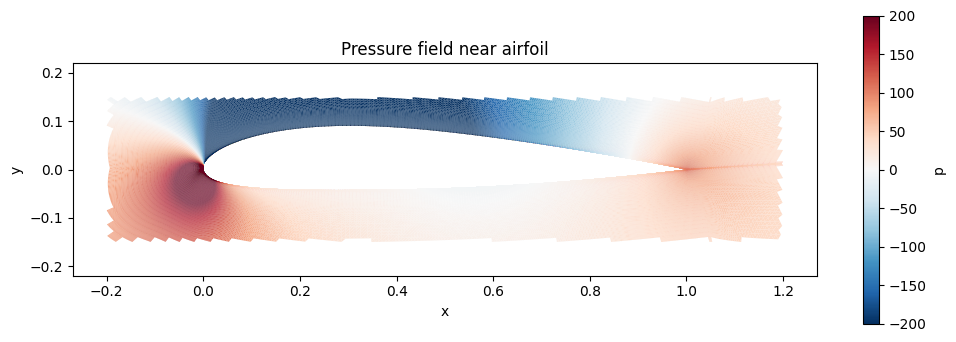

In [24]:
import matplotlib.pyplot as plt

# Slice to the near-airfoil region for a focused view
mask = (
    (dm.interior.points[:, 0] > -0.2)
    & (dm.interior.points[:, 0] < 1.2)
    & (dm.interior.points[:, 1] > -0.15)
    & (dm.interior.points[:, 1] < 0.15)
)
near_airfoil = dm.interior.slice_points(mask)

fig, ax = plt.subplots(figsize=(12, 4))
near_airfoil.draw(
    point_scalars="p", cmap="RdBu_r", show_edges=False,
    vmin=-200, vmax=200, backend="matplotlib", ax=ax, show=False,
)
ax.set_aspect("equal")
ax.set_title("Pressure field near airfoil")
plt.show()

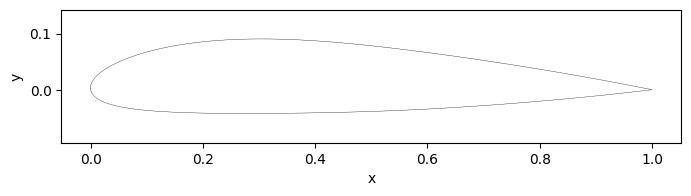

<Axes: xlabel='x', ylabel='y'>

In [25]:
# The airfoil boundary itself (alpha_points=0 suppresses vertex markers)
dm.boundaries["airfoil"].draw(backend="matplotlib", alpha_points=0)

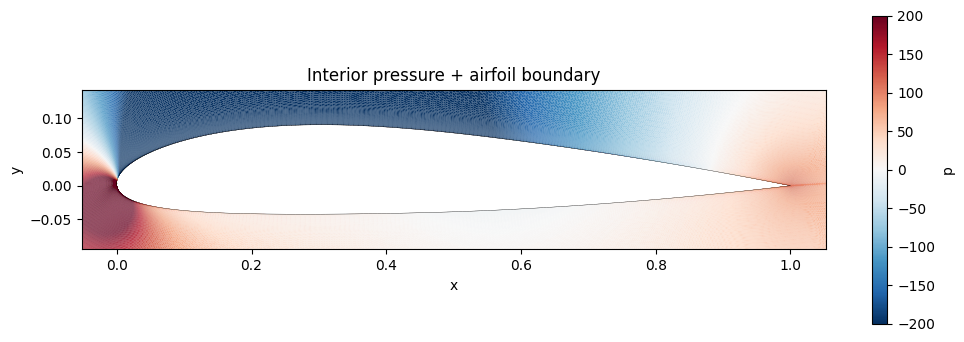

In [26]:
# Interior pressure field with the airfoil boundary overlaid
fig, ax = plt.subplots(figsize=(12, 4))
near_airfoil.draw(
    point_scalars="p", cmap="RdBu_r", show_edges=False,
    vmin=-200, vmax=200, backend="matplotlib", ax=ax, show=False,
)
dm.boundaries["airfoil"].draw(backend="matplotlib", ax=ax, alpha_points=0, show=False)
ax.set_aspect("equal")
ax.set_title("Interior pressure + airfoil boundary")
plt.show()

## Section 6: Domain-Wide Operations with `apply()`

Every built-in operation (`clean`, `subdivide`, `rotate`, ...) delegates to a single
primitive: `apply(fn)`, which maps a `Mesh -> Mesh` function over the interior and
every boundary. You can use `apply` directly for custom transformations.

All methods return a new `DomainMesh` and support fluent chaining.

  interior    : 180790 points,     0 cells
  airfoil     :   1018 points,     0 cells
  freestream  :   1728 points,     0 cells


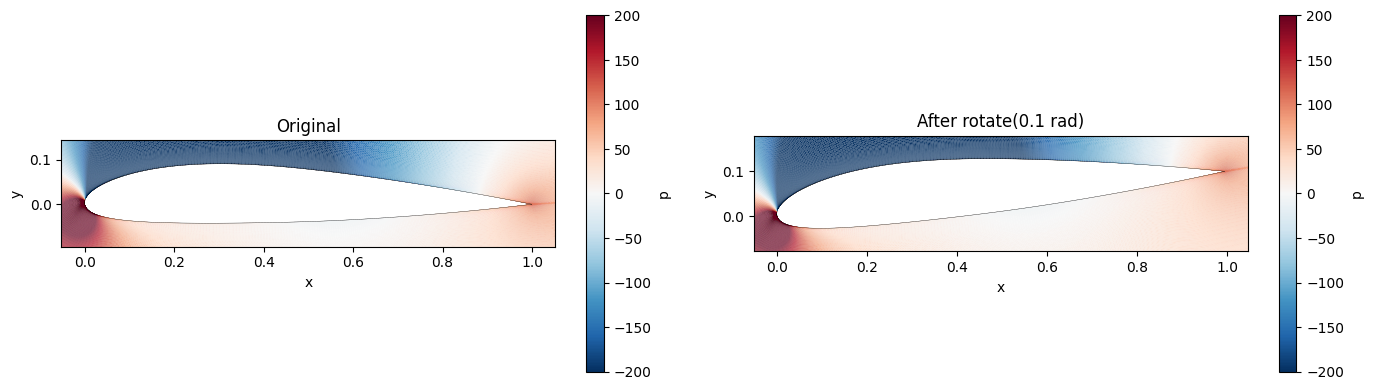

In [27]:
# apply() maps any Mesh -> Mesh function over the entire domain.
# Here: strip all meshes to point clouds (drop connectivity).
dm_cloud = dm.apply(lambda m: Mesh(points=m.points, point_data=m.point_data))

for name, mesh in dm_cloud:
    print(f"  {name:12s}: {mesh.n_points:6d} points, {mesh.n_cells:5d} cells")

# Visualize the rotated domain from Section 3 alongside the original
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

near_airfoil.draw(
    point_scalars="p", cmap="RdBu_r", show_edges=False,
    vmin=-200, vmax=200, backend="matplotlib", ax=ax1, show=False,
)
dm.boundaries["airfoil"].draw(backend="matplotlib", ax=ax1, alpha_points=0, show=False)
ax1.set_aspect("equal")
ax1.set_title("Original")

# Slice the rotated domain's interior to the same region
rot_mask = (
    (dm_rotated.interior.points[:, 0] > -0.2)
    & (dm_rotated.interior.points[:, 0] < 1.2)
    & (dm_rotated.interior.points[:, 1] > -0.15)
    & (dm_rotated.interior.points[:, 1] < 0.25)
)
near_rotated = dm_rotated.interior.slice_points(rot_mask)
near_rotated.draw(
    point_scalars="p", cmap="RdBu_r", show_edges=False,
    vmin=-200, vmax=200, backend="matplotlib", ax=ax2, show=False,
)
dm_rotated.boundaries["airfoil"].draw(backend="matplotlib", ax=ax2, alpha_points=0, show=False)
ax2.set_aspect("equal")
ax2.set_title("After rotate(0.1 rad)")

plt.tight_layout()
plt.show()

## Summary

`DomainMesh` provides a standardized representation for simulation domains:

- **Three fields**: `interior` (the mesh), `boundaries` (named BC patches),
  `global_data` (domain parameters)
- **Real data**: Loads directly from VTK files via PyVista, with `project()` for
  dimensional reduction
- **Domain-wide operations**: `translate`, `rotate`, `scale`, `subdivide`, `clean`,
  `validate` propagate to every mesh in the domain
- **Data augmentation**: Geometric transforms with `transform_point_data=True`
  co-rotate vector fields, enabling training-time augmentation for non-equivariant
  models
- **Validation**: `validate()` aggregates quality checks across interior and all
  boundaries

This is the foundation for standardized PDE problem representations, enabling
reusable datapipes that work across datasets and model architectures.